In [32]:
import tensorflow as tf
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [33]:
from transformers import BertTokenizer, TFBertForSequenceClassification
from tqdm.notebook import tqdm
from sklearn.metrics import confusion_matrix, classification_report

In [34]:
MODEL_NAME = "blanchefort/rubert-base-cased-sentiment"
BATCH_SIZE = 64
sns.set_theme(style="whitegrid", context="talk")

In [35]:
print(f"Загрузка модели: {MODEL_NAME}...")
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
model = TFBertForSequenceClassification.from_pretrained(MODEL_NAME, use_safetensors=False)

df_path = '/content/drive/MyDrive/Colab Notebooks/Third semester/Fine-Tuning/RuBert-Data/rusentitweet_test_cleaned 2.csv'
df = pd.read_csv(df_path)

df['label'] = df['label'].str.lower().str.strip()

print(f"Модель загружена. Размер датасета: {df.shape[0]} строк.")
df.head(3)

Загрузка модели: blanchefort/rubert-base-cased-sentiment...


Some layers from the model checkpoint at blanchefort/rubert-base-cased-sentiment were not used when initializing TFBertForSequenceClassification: ['dropout_37']
- This IS expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertForSequenceClassification were initialized from the model checkpoint at blanchefort/rubert-base-cased-sentiment.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertForSequenceClassification for predictions without further training.


Модель загружена. Размер датасета: 2211 строк.


,text,label,id
0,я считаю это мем года https://t.co/xoVKj5y8Mj,positive,1218052288964632576
1,ян русский на сотку все запятые где надо🤙🏻👍🏻👍🏻...,positive,1212859589592539136
2,@daria_karapet * терияки бойз начинает играть*,neutral,1321540138334302209


In [36]:
def batch_predict(text_list, batch_size=32):
    """Пакетная обработка текстов на GPU."""
    all_labels = []
    labels_map = ['neutral', 'positive', 'negative']

    for i in tqdm(range(0, len(text_list), batch_size), desc="Анализ тональности"):
        batch_texts = text_list[i : i + batch_size]

        # Токенизация
        inputs = tokenizer(batch_texts, max_length=512, padding=True, truncation=True, return_tensors='tf')

        # Инференс
        logits = model(inputs).logits
        probs = tf.nn.softmax(logits, axis=-1).numpy()

        # Декодирование
        for prob in probs:
            all_labels.append(labels_map[np.argmax(prob)])

    return all_labels


print("Запуск инференса на GPU...")
clean_texts = df['text'].astype(str).tolist()

# Предсказание
df['rubert_pred'] = batch_predict(clean_texts, batch_size=BATCH_SIZE)

# df.to_csv('rubert_baseline_results.csv', index=False)
print("Обработка завершена.")

Запуск инференса на GPU...


Анализ тональности:   0%|          | 0/35 [00:00<?, ?it/s]

Обработка завершена.


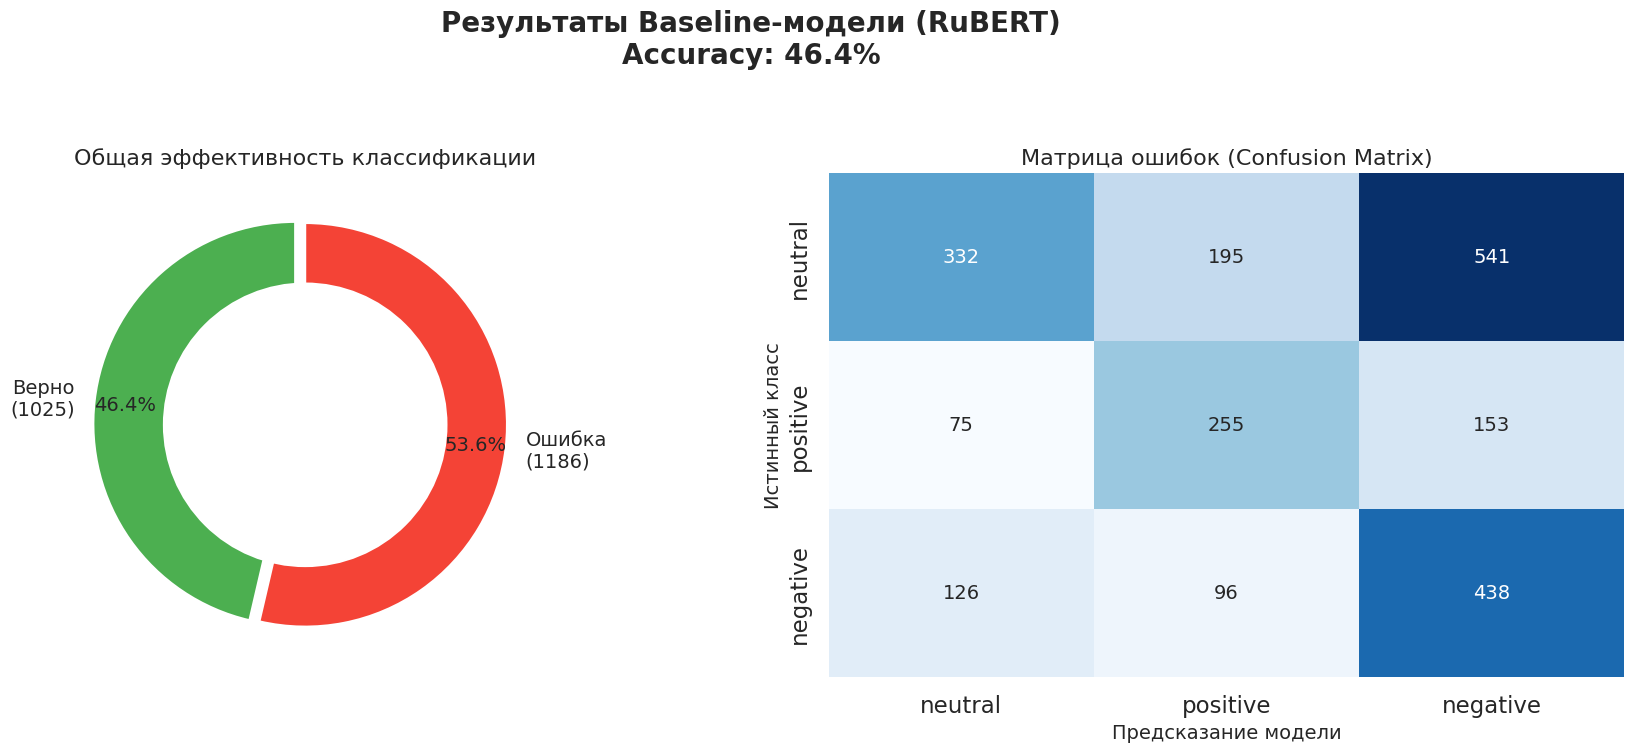

              precision    recall  f1-score   support

     neutral       0.39      0.66      0.49       660
    positive       0.62      0.31      0.41      1068
    negative       0.47      0.53      0.50       483

    accuracy                           0.46      2211
   macro avg       0.49      0.50      0.47      2211
weighted avg       0.52      0.46      0.45      2211



In [37]:
# Подготовка данных для графиков
correct = (df['label'] == df['rubert_pred']).sum()
total = len(df)
accuracy = correct / total

# Полотно для двух графиков
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
plt.suptitle(f'Результаты Baseline-модели (RuBERT)\nAccuracy: {accuracy:.1%}', fontsize=20, weight='bold')

# Общая точность
labels = [f'Верно\n({correct})', f'Ошибка\n({total - correct})']
sizes = [correct, total - correct]
colors = ['#4CAF50', '#F44336']
explode = (0.05, 0)

axes[0].pie(sizes, colors=colors, labels=labels, autopct='%1.1f%%', startangle=90, pctdistance=0.85, explode=explode, textprops={'fontsize': 14})

centre_circle = plt.Circle((0,0), 0.70, fc='white')
axes[0].add_artist(centre_circle)
axes[0].set_title('Общая эффективность классификации', fontsize=16)

# Confusion Matrix
classes = ['neutral', 'positive', 'negative']
cm = confusion_matrix(df['label'], df['rubert_pred'], labels=classes)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=classes, yticklabels=classes, ax=axes[1], annot_kws={"size": 14})

axes[1].set_title('Матрица ошибок (Confusion Matrix)', fontsize=16)
axes[1].set_xlabel('Предсказание модели', fontsize=14)
axes[1].set_ylabel('Истинный класс', fontsize=14)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print(classification_report(df['label'], df['rubert_pred'], target_names=classes))